<a href="https://colab.research.google.com/github/peperjet/deep-learning/blob/main/RNN_Text_Classification/10_4_imdb_movie_review_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

이 자료는 위키독스 딥 러닝을 이용한 자연어 처리 입문의 IDMB 리뷰 감성 분류하기 튜토리얼입니다.

링크 : https://wikidocs.net/24586

이 자료는 2021년 10월 13일에 마지막으로 테스트되었습니다.

1. IMDB 리뷰 데이터에 대한 이해

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb

In [2]:
(X_train, y_train), (X_test, y_test) = imdb.load_data()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print('훈련용 리뷰 개수 : {}'.format(len(X_train)))
print('테스트용 리뷰 개수 : {}'.format(len(X_test)))
num_classes = len(set(y_train))
print('카테고리 : {}'.format(num_classes))

훈련용 리뷰 개수 : 25000
테스트용 리뷰 개수 : 25000
카테고리 : 2


In [4]:
print(X_train[0])
print(y_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
1


리뷰의 최대 길이 : 2494
리뷰의 평균 길이 : 238.71364


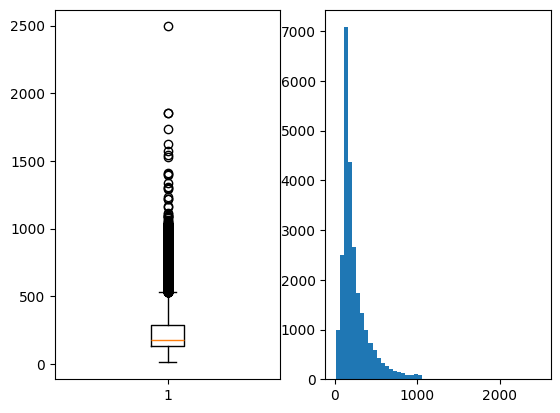

In [5]:
len_result = [len(s) for s in X_train]

print('리뷰의 최대 길이 : {}'.format(np.max(len_result)))
print('리뷰의 평균 길이 : {}'.format(np.mean(len_result)))

plt.subplot(1,2,1)
plt.boxplot(len_result)
plt.subplot(1,2,2)
plt.hist(len_result, bins=50)
plt.show()

In [6]:
unique_elements, counts_elements = np.unique(y_train, return_counts=True)
print("각 레이블에 대한 빈도수:")
print(np.asarray((unique_elements, counts_elements)))

각 레이블에 대한 빈도수:
[[    0     1]
 [12500 12500]]


In [7]:
word_to_index = imdb.get_word_index()
index_to_word={}
for key, value in word_to_index.items():
    index_to_word[value+3] = key

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
print('빈도수 상위 1등 단어 : {}'.format(index_to_word[4]))

빈도수 상위 1등 단어 : the


In [9]:
print('빈도수 상위 3938등 단어 : {}'.format(index_to_word[3941]))

빈도수 상위 3938등 단어 : suited


- value+3을 직접 해버렸음
- 빈도수 산위 1등 단어 : the
- the -> 4번 인덱스로 이동
- 1등 단어 -> index 4
- 3938등 단어 -> 3938 + 3 =3941

In [10]:
for index, token in enumerate(("", "", "")):
    index_to_word[index]=token

print(' '.join([index_to_word[index] for index in X_train[0]]))

 this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be 

2. GRU로 IMDB 리뷰 감성 분류하기

In [11]:
import re
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Embedding
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

In [12]:
vocal_size = 1000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocal_size)

In [13]:
max_len = 500
X_train = pad_sequences(X_train, maxlen = max_len)
X_test = pad_sequences (X_test, maxlen = max_len)

In [14]:
embedding_dim = 100
hidden_units = 128

model = Sequential()
model.add(Embedding(vocal_size, embedding_dim))
model.add(GRU(hidden_units))
model.add(Dense(1, activation='sigmoid'))

In [15]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=4)
mc = ModelCheckpoint('GRU_model.h5', monitor='val_acc', mode='max', verbose=1, save_best_only=True)

In [16]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(X_train, y_train, epochs=15, callbacks=[es, mc], batch_size=64, validation_split=0.2)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.5920 - loss: 0.6566
Epoch 1: val_acc improved from None to 0.77560, saving model to GRU_model.h5



Epoch 1: finished saving model to GRU_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 354s 1s/step - acc: 0.6664 - loss: 0.5995 - val_acc: 0.7756 - val_loss: 0.4753
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.7721 - loss: 0.5031
Epoch 2: val_acc did not improve from 0.77560
313/313 ━━━━━━━━━━━━━━━━━━━━ 374s 1s/step - acc: 0.7718 - loss: 0.4928 - val_acc: 0.7458 - val_loss: 0.5488
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.7940 - loss: 0.4513
Epoch 3: val_acc improved from 0.77560 to 0.81680, saving model to GRU_model.h5



Epoch 3: finished saving model to GRU_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 366s 1s/step - acc: 0.8041 - loss: 0.4353 - val_acc: 0.8168 - val_loss: 0.4409
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.8314 - loss: 0.3913
Epoch 4: val_acc improved from 0.81680 to 0.83400, saving model to GRU_model.h5



Epoch 4: finished saving model to GRU_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 344s 1s/step - acc: 0.8360 - loss: 0.3801 - val_acc: 0.8340 - val_loss: 0.3864
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.8619 - loss: 0.3261
Epoch 5: val_acc improved from 0.83400 to 0.84980, saving model to GRU_model.h5



Epoch 5: finished saving model to GRU_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 344s 1s/step - acc: 0.8602 - loss: 0.3289 - val_acc: 0.8498 - val_loss: 0.3475
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.8791 - loss: 0.2976
Epoch 6: val_acc improved from 0.84980 to 0.87000, saving model to GRU_model.h5



Epoch 6: finished saving model to GRU_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 346s 1s/step - acc: 0.8762 - loss: 0.3034 - val_acc: 0.8700 - val_loss: 0.3045
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.8875 - loss: 0.2797
Epoch 7: val_acc improved from 0.87000 to 0.87340, saving model to GRU_model.h5



Epoch 7: finished saving model to GRU_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 367s 1s/step - acc: 0.8881 - loss: 0.2761 - val_acc: 0.8734 - val_loss: 0.2959
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.8992 - loss: 0.2527
Epoch 8: val_acc improved from 0.87340 to 0.87400, saving model to GRU_model.h5



Epoch 8: finished saving model to GRU_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 361s 1s/step - acc: 0.8935 - loss: 0.2622 - val_acc: 0.8740 - val_loss: 0.3066
Epoch 9/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9041 - loss: 0.2425
Epoch 9: val_acc improved from 0.87400 to 0.87680, saving model to GRU_model.h5



Epoch 9: finished saving model to GRU_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 364s 1s/step - acc: 0.9026 - loss: 0.2452 - val_acc: 0.8768 - val_loss: 0.2917
Epoch 10/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9112 - loss: 0.2277
Epoch 10: val_acc did not improve from 0.87680
313/313 ━━━━━━━━━━━━━━━━━━━━ 367s 1s/step - acc: 0.9078 - loss: 0.2345 - val_acc: 0.8726 - val_loss: 0.3088
Epoch 11/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9139 - loss: 0.2166
Epoch 11: val_acc did not improve from 0.87680
313/313 ━━━━━━━━━━━━━━━━━━━━ 349s 1s/step - acc: 0.9119 - loss: 0.2243 - val_acc: 0.8540 - val_loss: 0.3517
Epoch 12/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9192 - loss: 0.2073
Epoch 12: val_acc did not improve from 0.87680
313/313 ━━━━━━━━━━━━━━━━━━━━ 349s 1s/step - acc: 0.9173 - loss: 0.2120 - val_acc: 0.8756 - val_loss: 0.3065
Epoch 13/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9246 - loss: 0.1965
Epoch 13: val_acc did not improve from 0.87680
313/313 

In [38]:
loaded_model = load_model('GRU_model.h5')
print("\n 테스트 정확도: %.4f" % (loaded_model.evaluate(X_test, y_test)[1]))


782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 114ms/step - acc: 0.8800 - loss: 0.2899

 테스트 정확도: 0.8800


In [40]:
def sentiment_predict(new_sentence):
    # 1. 영어/숫자/공백만 남기고 소문자화
    new_sentence = re.sub('[^0-9a-zA-Z ]', '', new_sentence).lower()

    # 2. 정수 인코딩
    encoded = []
    for word in new_sentence.split():
        try:
            # +3은 IMDB 데이터셋의 특별 토큰(패딩, 시작, 알 수 없음)을 위한 offset
            index = word_to_index[word] + 3

            # 모델 학습 때 설정한 vocal_size(1000) 범위를 벗어나지 않도록 체크
            if index < vocal_size:
                encoded.append(index)
            else:
                encoded.append(2)  # OOV (Out-Of-Vocabulary) 토큰으로 처리
        except KeyError:
            encoded.append(2)      # 사전에 없는 단어는 OOV 토큰으로 처리

    # 3. 패딩
    pad_sequence = pad_sequences([encoded], maxlen=max_len)

    # 4. 예측
    # DeprecationWarning을 해결하기 위해 예측 배열에서 명확하게 스칼라 값 추출
    score = float(loaded_model.predict(pad_sequence, verbose=0)[0][0])

    # 5. 출력
    if score > 0.5:
        print("{:.2f}% 확률로 긍정 리뷰입니다.".format(score * 100))
    else:
        print("{:.2f}% 확률로 부정 리뷰입니다.".format((1 - score) * 100))

In [41]:
test_input = "This movie was just way too overrated. The fighting was not professional and in slow motion. I was expecting more from a 200 million budget movie. The little sister of T.Challa was just trying too hard to be funny. The story was really dumb as well. Don't watch this movie if you are going because others say its great unless you are a Black Panther fan or Marvels fan."

sentiment_predict(test_input)

97.09% 확률로 부정 리뷰입니다.


In [42]:

test_input = " I was lucky enough to be included in the group to see the advanced screening in Melbourne on the 15th of April, 2012. And, firstly, I need to say a big thank-you to Disney and Marvel Studios. \
Now, the film... how can I even begin to explain how I feel about this film? It is, as the title of this review says a 'comic book triumph'. I went into the film with very, very high expectations and I was not disappointed. \
Seeing Joss Whedon's direction and envisioning of the film come to life on the big screen is perfect. The script is amazingly detailed and laced with sharp wit a humor. The special effects are literally mind-blowing and the action scenes are both hard-hitting and beautifully choreographed."

sentiment_predict(test_input)


96.38% 확률로 긍정 리뷰입니다.
